# Univariate forecasting with `numpyro_forecast`

Port of Pyro's [univariate forecasting tutorial](https://pyro.ai/examples/forecasting_i.html) (see also the [NumPyro write-up](https://juanitorduz.github.io/numpyro_forecasting-univariate/)).
We forecast **weekly BART ridership** with a random-walk local level, Fourier
seasonality and a Student-T likelihood, fit by SVI, and evaluate with CRPS.


In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from jax import random

from numpyro_forecast import Forecaster, eval_crps
from numpyro_forecast.datasets import load_bart_weekly
from numpyro_forecast.models import UnivariateForecaster
from numpyro_forecast.util import fourier_features

rng_key = random.PRNGKey(0)

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

Log weekly totals, split into 417 training weeks and 52 test weeks.

In [2]:
y = load_bart_weekly()  # (weeks, 1), log scale
future = 52
duration = y.shape[0]
t_train = duration - future

# Annual Fourier seasonality (~52.18 weeks/year).
covariates = fourier_features(duration, period=52.18, num_terms=10)
y_train, covariates_train = y[:t_train], covariates[:t_train]
print("duration", duration, "train", t_train, "features", covariates.shape[-1])

duration 469 train 417 features 20


## Fit with SVI

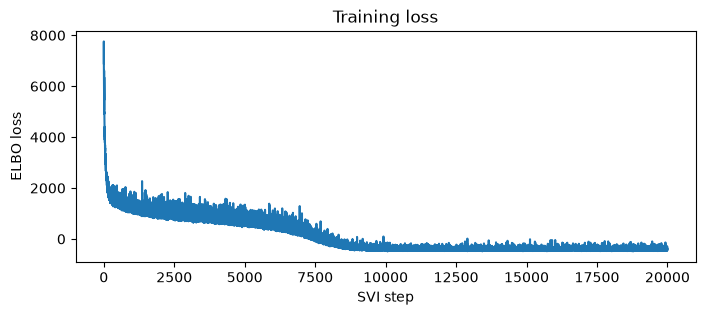

In [3]:
rng_key, key_fit = random.split(rng_key)
forecaster = Forecaster(
    UnivariateForecaster(),
    y_train,
    covariates_train,
    num_steps=20_000,
    rng_key=key_fit,
)
plt.figure(figsize=(8, 3))
plt.plot(forecaster.losses)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training loss");

## Forecast and evaluate

In [4]:
rng_key, key_fc = random.split(rng_key)
pred = forecaster(y_train, covariates, num_samples=2_000, rng_key=key_fc)
truth = y[t_train:]
print("forecast shape", pred.shape)
print("test CRPS", round(eval_crps(pred, truth), 4))

forecast shape (2000, 52, 1)
test CRPS 0.0455


## Plot the forecast (ArviZ >= 1.0)

We use `az.plot_lm` (the replacement for the legacy `az.plot_hdi`) to draw the
forecast HDI band against the held-out observations.

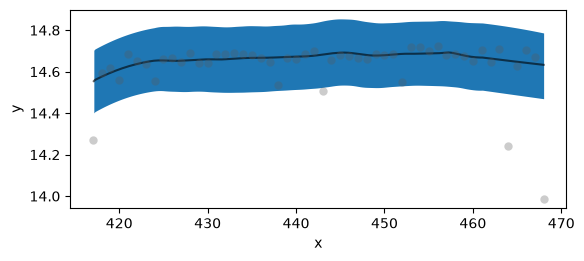

In [5]:
fc = np.asarray(pred[:, :, 0])  # (sample, time)
time = np.arange(t_train, duration).astype(float)
idata = az.from_dict(
    {
        "posterior_predictive": {"y": fc[None]},  # (chain=1, draw, time)
        "observed_data": {"y": np.asarray(truth[:, 0])},
        "constant_data": {"x": time},
    },
    coords={"time": time},
    dims={"y": ["time"], "x": ["time"]},
)
az.plot_lm(idata, y="y", x="x", ci_kind="hdi", ci_prob=0.94);

### Full series view

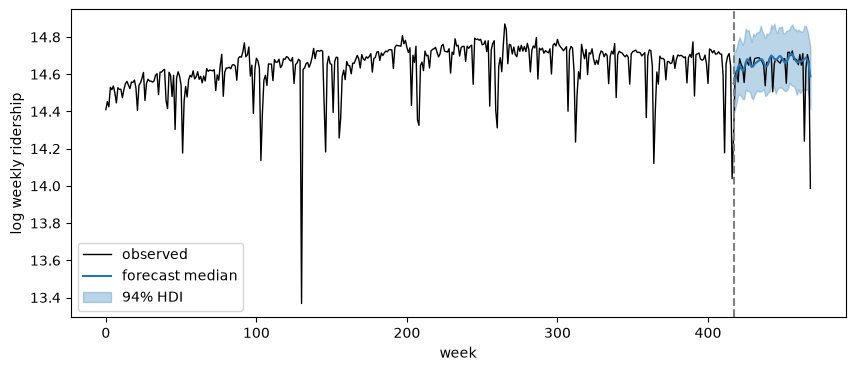

In [6]:
lo, mid, hi = np.percentile(fc, [3, 50, 97], axis=0)
plt.figure(figsize=(10, 4))
plt.plot(np.arange(duration), np.asarray(y[:, 0]), color="black", lw=1, label="observed")
plt.plot(time, mid, color="C0", label="forecast median")
plt.fill_between(time, lo, hi, color="C0", alpha=0.3, label="94% HDI")
plt.axvline(t_train, color="gray", ls="--")
plt.legend()
plt.xlabel("week")
plt.ylabel("log weekly ridership");